# ND Filter Test

In [1]:
! pip install uncertainties

In [1]:
1

1

In [181]:
import pandas as pd
import geopandas as gpd
import numpy as np
from datetime import date
import matplotlib.pyplot as plt
import glob
import scipy.io
import seaborn as sns
from uncertainties import ufloat
from uncertainties import unumpy

import hrzn_utils

In [182]:
angles_ssd, angles_fwd, widths_ssd, pathlength_ssd = hrzn_utils.load_in_hrzn_parameters()

we have: 36 measurements to process


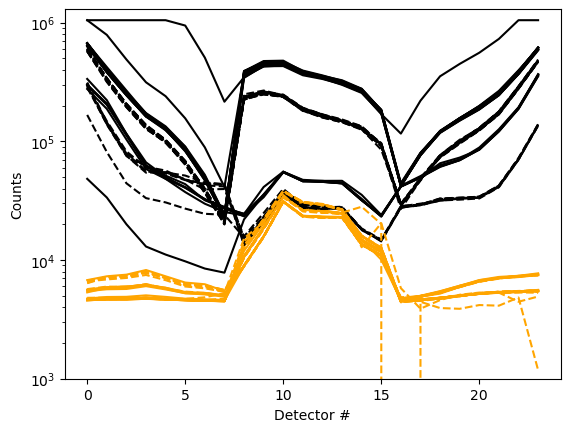

** Data rows removed due to light-dark error **
   0 row(s) removed
** Data rows removed due to saturation **
   scatSsdRawLight, 3 row(s) removed
   scatSsdRawDark, 0 row(s) removed


In [183]:
import importlib
importlib.reload(hrzn_utils)

# Get a list of all CSV files matching the pattern

# directory = 'data/nd_filter_090126/'
directory = 'data/nd_filter_090126/no_filter/'
specific_zscat_file = ['data/lisst_intercal/2025-06-13_11_52_25.csv'] # clean milliq blank
# specific_zscat_file = ['data/et_optics_june12_2025/2025-06-12_18_48_10.csv'] # sample 1 (oldest) filtrate

# directory = 'data/lisst_intercal/'
# this is the highly filtered milliQ blank
# specific_zscat_file = ['data/lisst_intercal/2025-06-13_11_52_25.csv']
# maybe this is the filtered seawater? need to go and check my notes
# specific_zscat_file = ['data/lisst_intercal/2025-06-13_11_17_23.csv']

###

pattern = '*.csv'
csv_files = glob.glob(directory + pattern)


processed, monte_carlo_results_0, monte_carlo_results_90, cscatFwd_monte_carlo = hrzn_utils.full_process(csv_files, using_fscat=False, apply_atten_corr=True, subtract_zscat=True, empirical_corr_factor=True)#, specific_zscat_file=specific_zscat_file)

processed['utc_dt'] = processed.datetime
processed = processed.set_index('utc_dt')
processed = processed.sort_index(ascending=True)
# horizon_df = horizon_df.iloc[1:]

In [185]:
# sample names for Dec 4th 2025 data

samples = [ 'nd filter with black tape holding it, some kind of issue with this one',
            'nd filter with black tape holding it',
            'nd filter with black tape holding it, beam c issues',
          'nd filter with black tape holding it, beam c issues',
          'nd filter with black tape holding it',
          'nd filter with black tape holding it',
          'AZ dust with ND filter, 700nm beads detectable',
          'AZ dust with ND filter',
          'AZ dust with ND filter',
          'AZ dust with ND filter higher concentration',
          'AZ dust with ND filter higher concentration']

samples = ['AZ dust no filter',
          'AZ dust no filter']

In [186]:
len(processed.sample_id.unique())

2

In [187]:
len(samples)

2

In [188]:
processed.sample_id.unique()

array([1, 2])

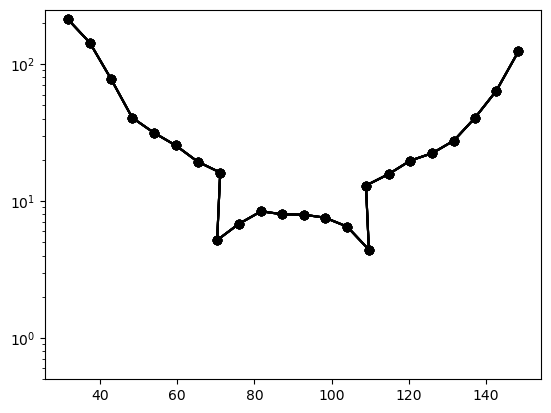

In [199]:
plt.plot(angles_ssd,np.vstack(samp_df[samp_df.polarizationAngle==0].zscatSsd_scaled).T, c='k', marker='o')
plt.ylim(.5,250)
plt.yscale('log')
plt.savefig('figs/zscat0_withOUT_filter.png',dpi=300,transparent=True)

0
AZ dust no filter
1.1449558447535724


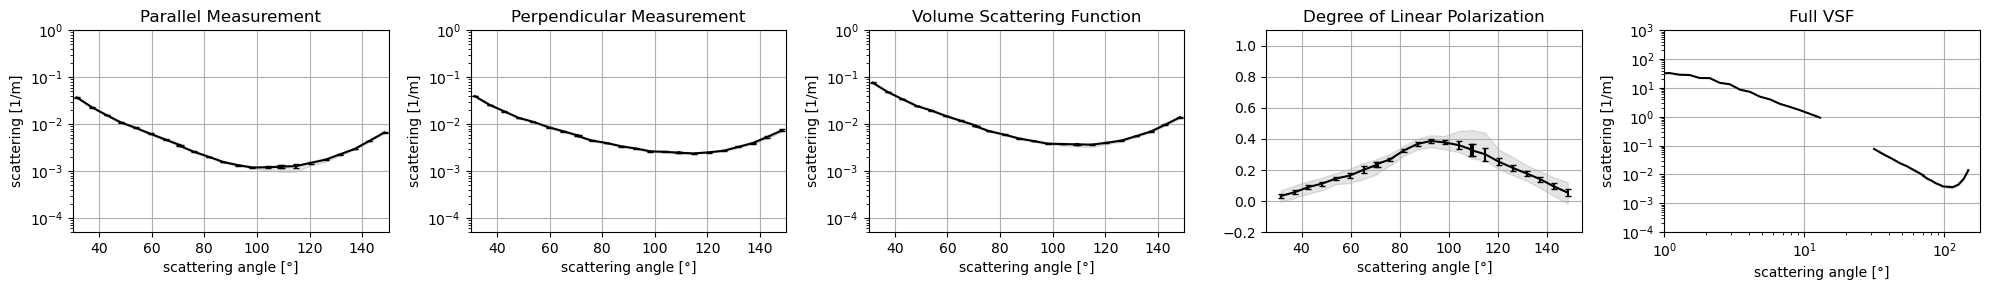

1
AZ dust no filter
1.2072027312753835


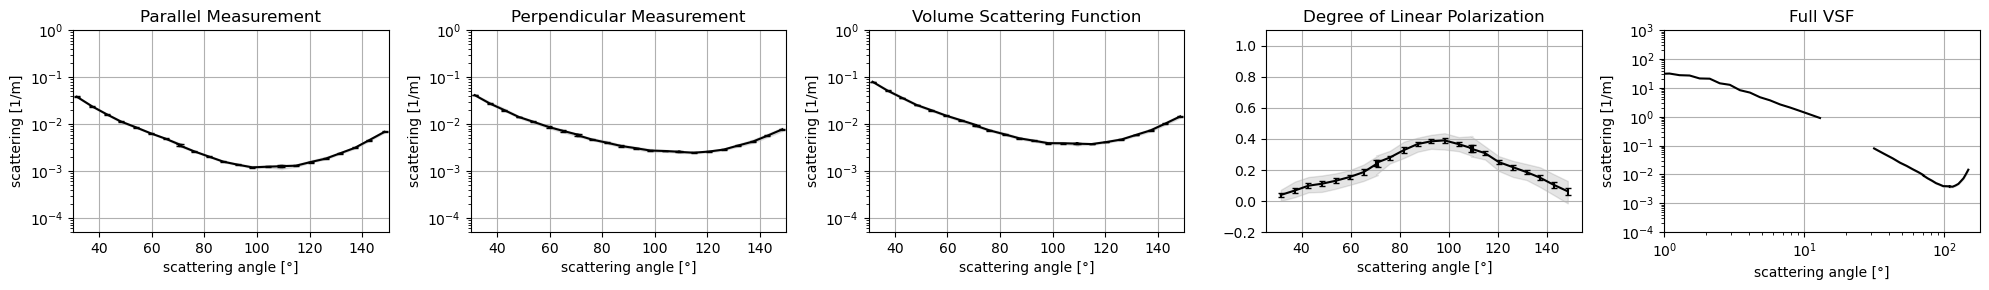

In [189]:
count = 0
mie_count = 20 # 10 is 2um 20 is 0.7um


for idx, sid in enumerate(processed.sample_id.unique()):
    samp_df = processed[processed.sample_id == sid]
    # print(samp_df.beamc)

    # if idx not in list(range(14,27))+ list(range(44,52)):
    #     count +=1
    #     continue
    # if sid not in [33, 34, 35, 36]:
    #     count += 1
    #     continue

    # if idx not in [29,30]: # az dust covered
    # if idx not in [31,32]: # az dust covered

    # if idx not in [21,22,25,26]: # 2um beads simple
    # if idx not in [21,22,23,24,25,26,27,28]: # all 2um beads
    # if idx not in [6,7,8,9,10,11,12,13,14,15,16,17,18]: # 700nm bead dilutions
    # if idx not in  [6,7,8,9]: # simple 700nm comparison with and without felt
    # if idx not in [0,1,2,3,4,5]: # 700nm unsuccessful felt variations 
    # if sid not in [33,34,35,36]: # AZ test dust
    # if idx not in [7,8,12,13,17,18]: # 700nm beads only without felt

    
    # if idx not in  [1,4,5]: # 700nm beads
    #     count += 1
    #     continue

    # if idx not in  [8,9,10]: # AZTD
    #     count += 1
    #     continue




    print(idx)

    if len(samp_df)==0:
        print(sid)
        continue
    # if np.median(samp_df.beamc) > 5:
    #     mie_count +=1
    #     continue
    # print(idx)

    fig, ax = plt.subplots(1,5, figsize=(20,3))

    

    

    print(samples[idx])
    # print(bead_diams[idx])
    print(np.median(samp_df.beamc))

    beamc_median = np.median(samp_df[samp_df.polarizationAngle==0].beamc)
    # beamc_median = 1 # 1 is the 700nm beads and 0.4 is the 2um beads

    # mie_perp = (mie_perp_raw[mie_count]+mie_para_raw[mie_count]*.03)*beamc_median
    # mie_para = (mie_para_raw[mie_count]+mie_perp_raw[mie_count]*.03)*beamc_median

    # mie_s11 = mie_perp + mie_para
    # mie_s12 = mie_para - mie_perp
    # mie_dolp = -mie_s12/mie_s11
    
    # ax[1].plot(full_angles_mie,mie_perp,c='grey')
    # ax[0].plot(full_angles_mie,mie_para,c='grey')
    # ax[2].plot(full_angles_mie,mie_s11,c='grey')
    # ax[4].plot(full_angles_mie,mie_s11,c='grey')
    # ax[3].plot(full_angles_mie,mie_dolp,c='grey')

    # ax[1].scatter(angles_ssd,mie_perp_modeled[mie_count]*beamc_median,c='grey')
    # ax[0].scatter(angles_ssd,mie_para_modeled[mie_count]*beamc_median,c='grey')
    # ax[2].scatter(angles_ssd,mie_para_modeled[mie_count]*beamc_median+mie_perp_modeled[mie_count]*beamc_median,c='grey')
    # ratio = mie_para_modeled[mie_count]/mie_perp_modeled[mie_count]
    # dolp = -1*((ratio-1) / (ratio+1))
    # ax[3].scatter(angles_ssd,dolp,c='grey')
    
    for i in range(len(samp_df[samp_df.polarizationAngle==0])):
        for j in range(len(samp_df[samp_df.polarizationAngle==90])):
            perp = samp_df[samp_df.polarizationAngle==90].cscatSsdUncal.iloc[j]
            para = samp_df[samp_df.polarizationAngle==0].cscatSsdUncal.iloc[i]
            beamc = samp_df[samp_df.polarizationAngle==0].beamc.iloc[i]

            mirror_perp = samp_df[samp_df.polarizationAngle==90].cscatSsdMirror.iloc[j]
            mirror_para = samp_df[samp_df.polarizationAngle==0].cscatSsdMirror.iloc[i]

            ratio = perp/para
            dolp = -1*((ratio-1) / (ratio+1))

            # ax[0].plot(angles_ssd,perp,marker='o')
            # ax[0].plot(angles_ssd,mirror_perp,marker='o',c='grey')
            # ax[1].plot(angles_ssd,mirror_para,marker='o',c='grey')
            # ax[1].plot(angles_ssd,para,marker='o')
            # ax[2].plot(angles_ssd,(perp+para),marker='o')
            # ax[3].plot(angles_ssd,dolp,marker='o')

            # ax[4].plot(angles_ssd,dolp,marker='o')

    

    # cscatFwd = np.vstack(samp_df[samp_df.polarizationAngle==0].cscatFwd)
    tau = np.vstack(samp_df[samp_df.polarizationAngle==0].tau)
    zscatFwd = np.median(np.vstack(samp_df[samp_df.polarizationAngle==0].zscatFwd_scaled),axis=0)
    vsf_ssd = (np.nanmedian(np.vstack(samp_df[samp_df.polarizationAngle==0].cscatSsdUncal),axis=0)+np.nanmedian(np.vstack(samp_df[samp_df.polarizationAngle==90].cscatSsdUncal),axis=0))
    # print('ratio of <2.5° to >2.5°')
    # print(np.trapz(cscatFwd[5,:26], x=angles_fwd[:26]) / np.trapz(cscatFwd[5,26:], x=angles_fwd[26:]))
    # print('ratio of last fwd to first ssd')
    # print(np.median(cscatFwd[:,-1])/vsf_ssd[0])

    color = 'k'

    # ax[4].plot(angles_fwd, np.array(cscatFwd_monte_carlo[count]).reshape(-1,36).T,c='grey',alpha=0.05)
    ax[4].plot(angles_fwd, np.nanmedian(np.array(cscatFwd_monte_carlo[count]).reshape(-1,36),axis=0),c='k')
    # ax[4].plot(angles_fwd, cscatFwd.T,c=color)
    
    # ax[4].plot(angles_fwd, zscatFwd.T,c='grey')
    # ax[4].plot(angles_ssd, vsf_ssd)

    pol0 = np.array(monte_carlo_results_0[count])
    pol90 = np.array(monte_carlo_results_90[count])
    
    med0 = np.nanmedian(pol0,axis=(0,1))
    std0 = np.nanstd(pol0,axis=(0,1))
    # ax[1].plot(angles_ssd,med0,c='k',lw=3)
    # ax[1].plot(angles_ssd,med0+std0,c='k',ls='--')
    # ax[1].plot(angles_ssd,med0-std0,c='k',ls='--')
    ax[1].errorbar(angles_ssd,med0, std0,capsize=2,c=color)
    
    med90 = np.nanmedian(pol90,axis=(0,1))
    std90 = np.nanstd(pol90,axis=(0,1))

    min90 = np.nanmin(pol90,axis=(0,1))
    max90 = np.nanmax(pol90,axis=(0,1))
    min0  = np.nanmin(pol0,axis=(0,1))
    max0  = np.nanmax(pol0,axis=(0,1))

    min90[min90 < 0] =0
    min0[min0 < 0] =0
    


    # med90[med90 < 0.00001] = np.nan
    # med0[med0 < 0.00001] = np.nan
    
    # ax[0].plot(angles_ssd,med90,c='k',lw=3)
    # ax[0].plot(angles_ssd,med90+std90,c='k',ls='--')
    # ax[0].plot(angles_ssd,med90-std90,c='k',ls='--')
    # ax[0].errorbar(angles_ssd,med90, std90,c=color,capsize=2)
    ax[0].errorbar(angles_ssd,med90, std90,capsize=2,c=color)

    s11_full = unumpy.uarray(med0, std0) + unumpy.uarray(med90, std90)
    s11_min = min90 + min0
    s11_max = max90 + max0
    
    s12_full = unumpy.uarray(med0, std0) - unumpy.uarray(med90, std90)
    # TODO make it so values below 0 are set to 0, we can't actually have a negative scattering value
    s12_min = min0 - max90
    s12_max = max0 - min90

    ratio = unumpy.uarray(med90, std90)/unumpy.uarray(med0, std0)
    dolp = -1*((ratio-1) / (ratio+1))

    ratio_max = max90/min0
    dolp_max = -1*((ratio_max-1) / (ratio_max+1))

    ratio_min = min90/max0
    dolp_min = -1*((ratio_min-1) / (ratio_min+1))

    dolp_min[np.isnan(dolp_min)] = 1
    dolp_max[np.isnan(dolp_max)] = -1

    # phase_fcn = s11_full / beamc_median

    ax[2].errorbar(angles_ssd,unumpy.nominal_values(s11_full), unumpy.std_devs(s11_full),capsize=2,c=color)
    ax[0].fill_between(angles_ssd, min90, max90,color='k',alpha=0.1)
    ax[1].fill_between(angles_ssd, min0, max0,color='k',alpha=0.1)
    ax[2].fill_between(angles_ssd,s11_min, s11_max,color='k',alpha=0.1)
    ax[3].fill_between(angles_ssd,dolp_min, dolp_max,color='k',alpha=0.1)
    ax[4].fill_between(angles_ssd,s11_min, s11_max,color='k',alpha=0.1)
    # ax[2].errorbar(angles_ssd,unumpy.nominal_values(phase_fcn), unumpy.std_devs(phase_fcn),c=color,capsize=2)
    # ax[2].plot(angles_ssd,unumpy.nominal_values(s11_full),c='k',lw=3)
    # ax[2].plot(angles_ssd,unumpy.nominal_values(s11_full)-unumpy.std_devs(s11_full),c='k',ls='--')
    # ax[2].plot(angles_ssd,unumpy.nominal_values(s11_full)+unumpy.std_devs(s11_full),c='k',ls='--')

    ax[4].plot(angles_ssd,unumpy.nominal_values(s11_full),c=color)
    # ax[4].plot(angles_ssd,unumpy.nominal_values(s11_full)-unumpy.std_devs(s11_full),c='k',ls='--')
    # ax[4].plot(angles_ssd,unumpy.nominal_values(s11_full)+unumpy.std_devs(s11_full),c='k',ls='--')

    # ax[3].plot(angles_ssd,unumpy.nominal_values(dolp),c='k',lw=3)
    ax[3].errorbar(angles_ssd,unumpy.nominal_values(dolp), unumpy.std_devs(dolp),capsize=2,c=color)
    # ax[3].plot(angles_ssd,unumpy.nominal_values(dolp)-unumpy.std_devs(dolp),c='k',ls='--')
    # ax[3].plot(angles_ssd,unumpy.nominal_values(dolp)+unumpy.std_devs(dolp),c='k',ls='--')

    ax[0].set_yscale('log')
    ax[1].set_yscale('log')
    ax[2].set_yscale('log')
    ax[4].set_yscale('log')
    ax[0].set_ylim(0.00005,1)
    ax[1].set_ylim(0.00005,1)
    ax[2].set_ylim(0.00005,1)
    ax[3].set_ylim(-0.2,1.1)
    ax[4].set_ylim(0.0001,1000)
    ax[4].set_xlim(1,180)
    ax[0].set_xlim(30,150)
    ax[1].set_xlim(30,150)
    ax[2].set_xlim(30,150)
    ax[4].set_xscale('log')

    
    # ax[0].set_xlim(.2,180)
    # ax[1].set_xlim(.2,180)
    # ax[2].set_xlim(.2,180)
    # ax[3].set_xlim(.2,180)

    ax[0].set_title('Parallel Measurement')
    ax[1].set_title('Perpendicular Measurement')
    ax[2].set_title('Phase Function')
    ax[2].set_title('Volume Scattering Function')
    ax[3].set_title('Degree of Linear Polarization')
    ax[4].set_title('Full VSF')

    ax[0].set_xlabel('scattering angle [°]')
    ax[1].set_xlabel('scattering angle [°]')
    ax[2].set_xlabel('scattering angle [°]')
    ax[3].set_xlabel('scattering angle [°]')
    ax[4].set_xlabel('scattering angle [°]')

    ax[0].set_ylabel('scattering [1/m]')
    ax[1].set_ylabel('scattering [1/m]')
    ax[2].set_ylabel('scattering [1/m]')
    # ax[2].set_ylabel('phase function [1/sr]')
    
    ax[3].set_ylabel('')
    ax[4].set_ylabel('scattering [1/m]')

    # ax[3].axhline(0.6)
    # ax[3].axvline(90)
    # ax[4].axhline(0.6)
    # ax[4].axvline(90)
    


    fig.tight_layout()

    # fig.savefig('figs/etoptics/poster'+samples[idx]+'.png',dpi=300,transparent=True)

    count +=1
    # mie_count +=1
    
    ax[0].grid()
    ax[1].grid()
    ax[2].grid()
    ax[3].grid()
    ax[4].grid()
        
    # fig.savefig('figs/nd_filter/AZD_with_NDfilter.png',dpi=300,transparent=True)
    plt.show()

In [81]:
med0

array([0.04427622, 0.02955929, 0.02134081, 0.01554303, 0.01263388,
       0.0098267 , 0.00781167, 0.00610068, 0.00609931, 0.00494518,
       0.00421439, 0.00344265, 0.00296205, 0.00244085, 0.00221417,
       0.00189536, 0.00189533, 0.00157988, 0.00141426, 0.00128856,
       0.00123392, 0.00110698, 0.00109571, 0.00092413])

In [6]:
value30 = .1

In [7]:
value150 = .001

In [12]:
ref0 = 0.16
refnew = ref0*.25

In [13]:
value30*refnew / value150

4.0

In [57]:
np.mean(pol90[:,:,-2].flatten())

0.0009763374273050809

<Axes: ylabel='Proportion'>

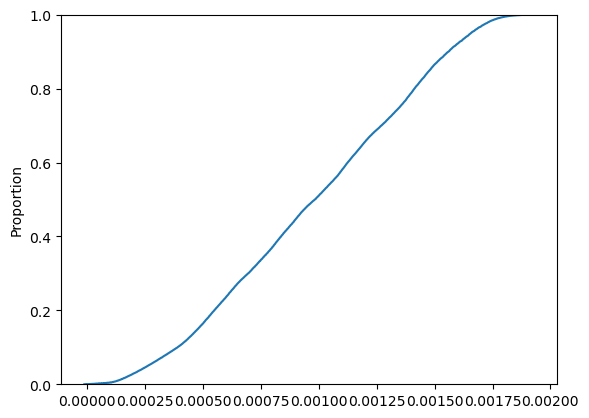

In [55]:
sns.ecdfplot(pol90[:,:,-2].flatten())

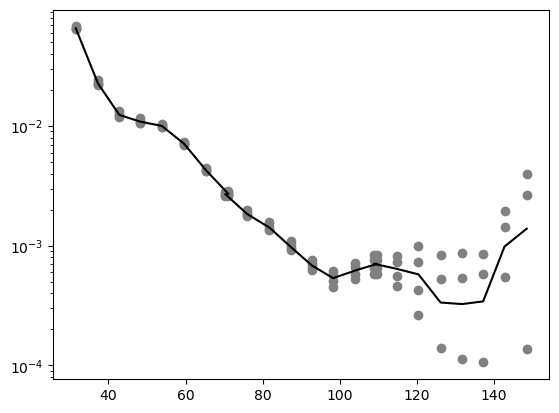

In [85]:
plt.plot(angles_ssd,np.median(pol90,axis=(0,1)),c='k')
plt.scatter(angles_ssd,np.min(pol90,axis=(0,1)),c='grey')
plt.scatter(angles_ssd,np.max(pol90,axis=(0,1)),c='grey')

plt.scatter(angles_ssd,np.median(pol90,axis=(0,1))+np.std(pol90,axis=(0,1)),c='grey')
plt.scatter(angles_ssd,np.median(pol90,axis=(0,1))-np.std(pol90,axis=(0,1)),c='grey')

# plt.ylim(-.005,0.005)

plt.yscale('log')

plt.show()


(array([ 7020.,  8250., 14550., 12320., 13360., 14090., 11335., 15350.,
         9515.,  3585.]),
 array([-1.09025737e-03, -5.85232095e-04, -8.02068203e-05,  4.24818455e-04,
         9.29843730e-04,  1.43486900e-03,  1.93989428e-03,  2.44491955e-03,
         2.94994483e-03,  3.45497010e-03,  3.95999538e-03]),
 <BarContainer object of 10 artists>)

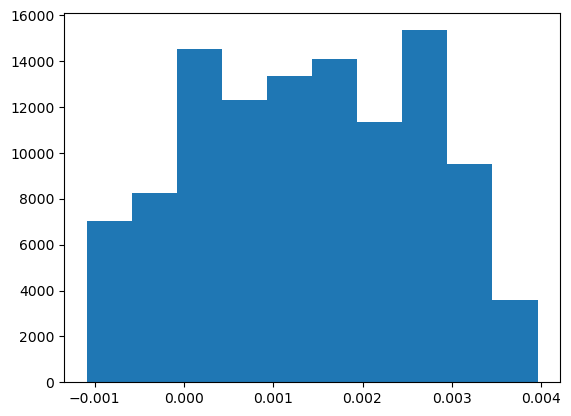

In [51]:
plt.hist(pol90[:,:,-1].flatten())

In [13]:
med0[-1]

0.0038550009769053235

In [16]:
0.013 - ( 0.066*1.12*.165 / np.exp(0.04*1/3) )

0.0009647446424699922

In [43]:
0.005 - ( 0.022*.9*.165 / np.exp(0.04*1/3) ), 0.005 - ( 0.022*1.1*.189 / np.exp(0.04*1/3) )

(0.0017762708863758915, 0.0004867792409262474)

In [33]:
np.exp(0.04*1/3)

1.0134226186043425

In this case the measured value at 150° is 0.013, yet with the felt covering the window it is 0.0002. But then the value being subtracted is (30° value x the reflection factor) 0.07 * 16.5% = 0.0115 which leaves us with 0.0015, but this is 7x higher than the correct value of 0.0002. This isn’t just uncertainty because the problem is persistent for asymmetrical particles like this.


In [41]:
(0.013 - 0.07*.165)

0.0014499999999999982

In [34]:
0.07 - 0.013*.165

0.06785500000000001

TODO see what factor is needed when I do the mirror correction to match the data with the felt covering

In [11]:
len(samples)

33

In [12]:
len(monte_carlo_results_90)

33

uncovered minus covered divided by the flip of the uncovered

TODO need to figure out uncertainty and also make sure I'm doing some kind of attenuation correction for these

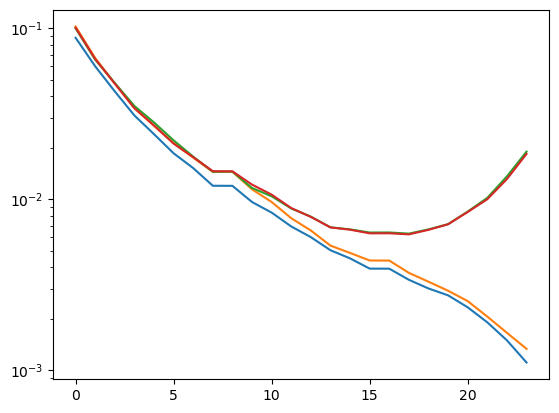

In [216]:
plt.plot(np.nanmedian(monte_carlo_results_0[29],axis=(0,1)))
plt.plot(np.nanmedian(monte_carlo_results_0[30],axis=(0,1)))

plt.plot(np.nanmedian(monte_carlo_results_0[31],axis=(0,1)))
plt.plot(np.nanmedian(monte_carlo_results_0[32],axis=(0,1)))

plt.yscale('log')

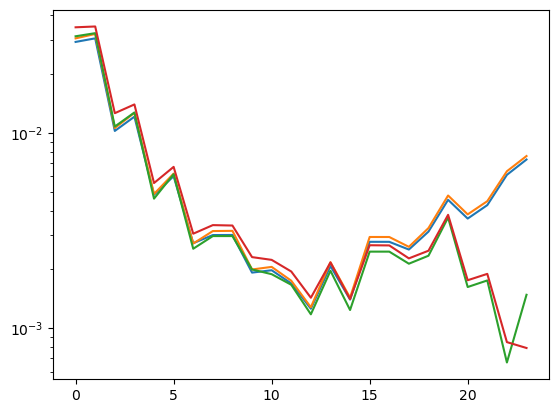

In [217]:
plt.plot(np.nanmedian(monte_carlo_results_0[21],axis=(0,1)))
plt.plot(np.nanmedian(monte_carlo_results_0[22],axis=(0,1)))

plt.plot(np.nanmedian(monte_carlo_results_0[25],axis=(0,1)))
plt.plot(np.nanmedian(monte_carlo_results_0[26],axis=(0,1)))

plt.yscale('log')

In [212]:
samples[9]

'felt side/back/full front 2'

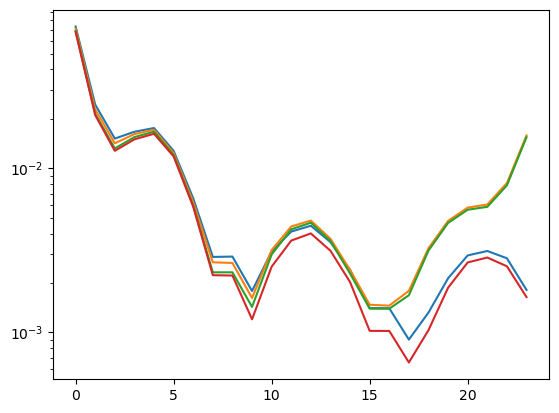

In [218]:
plt.plot(np.nanmedian(monte_carlo_results_0[6],axis=(0,1)))
plt.plot(np.nanmedian(monte_carlo_results_0[7],axis=(0,1)))

plt.plot(np.nanmedian(monte_carlo_results_0[8],axis=(0,1)))
plt.plot(np.nanmedian(monte_carlo_results_0[9],axis=(0,1)))

plt.yscale('log')

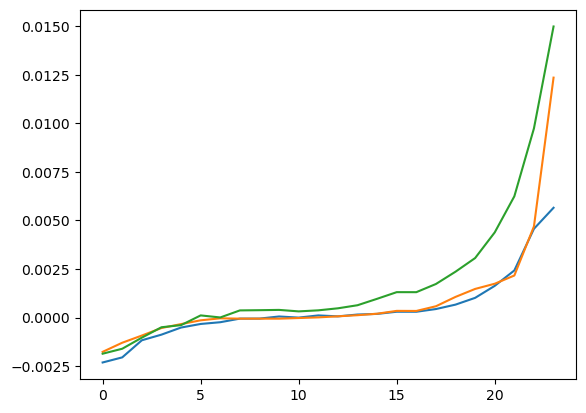

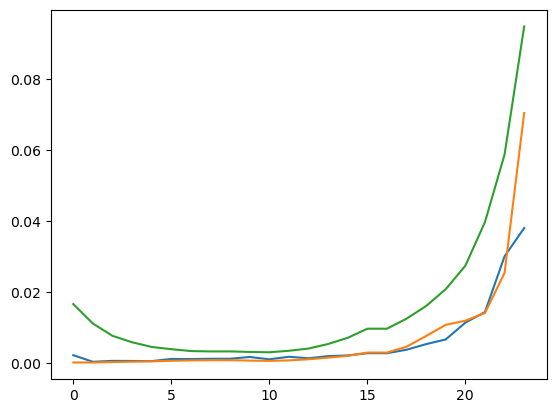

In [214]:
plt.plot(np.median(monte_carlo_results_90[21],axis=(0,1)) - np.median(monte_carlo_results_90[25],axis=(0,1)))
plt.plot((np.median(monte_carlo_results_90[7],axis=(0,1)) - np.median(monte_carlo_results_90[6],axis=(0,1))))
plt.plot((np.median(monte_carlo_results_90[32],axis=(0,1)) - np.median(monte_carlo_results_90[30],axis=(0,1))))

plt.show()

plt.plot(np.flip(np.median(monte_carlo_results_90[25],axis=(0,1))))
plt.plot(np.flip(np.median(monte_carlo_results_90[6],axis=(0,1))))
plt.plot(np.flip(np.median(monte_carlo_results_90[32],axis=(0,1))))
plt.show()

In [15]:
mirror_attenuation_pathlengths = np.array([169,154, 143, 135, 128, 121, 113, 106, 157, 150, 145, 141, 138, 135, 131, 126, 148, 146, 144, 142, 140, 139, 137, 136])/1000 - pathlength_ssd
atten_factor = widths_ssd

(-0.25, 0.25)

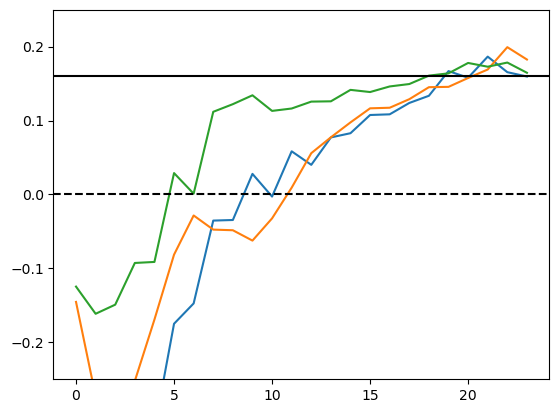

In [236]:



beamc = np.array(.6)
plt.plot(((np.median(monte_carlo_results_90[21],axis=(0,1)) - np.median(monte_carlo_results_90[25],axis=(0,1)))/ (np.flip(np.median(monte_carlo_results_90[21],axis=(0,1)))/(np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))))[0])
# plt.plot(((np.median(monte_carlo_results_90[21],axis=(0,1)) - np.median(monte_carlo_results_90[25],axis=(0,1)))/ (np.flip(np.median(monte_carlo_results_90[25],axis=(0,1)))/(np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))))[0])
beamc = np.array(1)
# plt.plot((np.median(monte_carlo_results_90[7],axis=(0,1)) - np.median(monte_carlo_results_90[6],axis=(0,1)))/np.flip(np.median(monte_carlo_results_90[6],axis=(0,1))))
plt.plot(((np.median(monte_carlo_results_90[7],axis=(0,1)) - np.median(monte_carlo_results_90[6],axis=(0,1)))/ (np.flip(np.median(monte_carlo_results_90[7],axis=(0,1)))/(np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))))[0])
# plt.plot(((np.median(monte_carlo_results_90[7],axis=(0,1)) - np.median(monte_carlo_results_90[6],axis=(0,1)))/ (np.flip(np.median(monte_carlo_results_90[6],axis=(0,1)))/(np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))))[0])
beamc = np.array(3)
# plt.plot((np.median(monte_carlo_results_90[32],axis=(0,1)) - np.median(monte_carlo_results_90[30],axis=(0,1)))/np.flip(np.median(monte_carlo_results_90[32],axis=(0,1))))
plt.plot(((np.median(monte_carlo_results_90[32],axis=(0,1)) - np.median(monte_carlo_results_90[30],axis=(0,1)))/ (np.flip(np.median(monte_carlo_results_90[32],axis=(0,1)))/(np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))))[0])
# plt.plot(((np.median(monte_carlo_results_90[32],axis=(0,1)) - np.median(monte_carlo_results_90[30],axis=(0,1)))/ (np.flip(np.median(monte_carlo_results_90[30],axis=(0,1)))/(np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))))[0])


plt.axhline(0.16,c='k')

plt.axhline(0,c='k',ls='--')

plt.ylim(-.25,.25)

In [196]:
np.nanmedian(monte_carlo_results_0[21],axis=(0,1))

array([0.02919779, 0.03045512, 0.01022602, 0.01209688, 0.00481935,
       0.00599919, 0.00272287, 0.00299711, 0.00300018, 0.00192541,
       0.00197963, 0.00169523, 0.00125815, 0.00208036, 0.0014014 ,
       0.00276783, 0.0027672 , 0.00252667, 0.00312148, 0.00454049,
       0.00364055, 0.00426572, 0.00609391, 0.00730078])

(-0.25, 0.25)

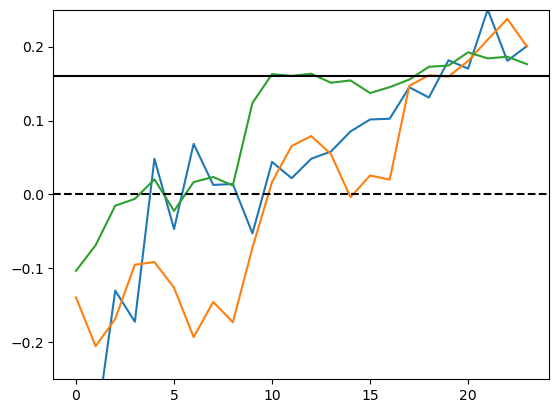

In [238]:
beamc = np.array(.6)
plt.plot(((np.nanmedian(monte_carlo_results_0[21],axis=(0,1)) - np.nanmedian(monte_carlo_results_0[25],axis=(0,1)))/ (np.flip(np.nanmedian(monte_carlo_results_0[21],axis=(0,1)))/(np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))))[0])
beamc = np.array(1)
# plt.plot((np.median(monte_carlo_results_90[7],axis=(0,1)) - np.median(monte_carlo_results_90[6],axis=(0,1)))/np.flip(np.median(monte_carlo_results_90[6],axis=(0,1))))
plt.plot(((np.nanmedian(monte_carlo_results_0[7],axis=(0,1)) - np.nanmedian(monte_carlo_results_0[6],axis=(0,1)))/ (np.flip(np.nanmedian(monte_carlo_results_0[7],axis=(0,1)))/(np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))))[0])
beamc = np.array(3)
# plt.plot((np.median(monte_carlo_results_90[32],axis=(0,1)) - np.median(monte_carlo_results_90[30],axis=(0,1)))/np.flip(np.median(monte_carlo_results_90[32],axis=(0,1))))
plt.plot(((np.nanmedian(monte_carlo_results_0[32],axis=(0,1)) - np.nanmedian(monte_carlo_results_0[30],axis=(0,1)))/ (np.flip(np.nanmedian(monte_carlo_results_0[32],axis=(0,1)))/(np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))))[0])

plt.axhline(0.16,c='k')

plt.axhline(0,c='k',ls='--')

plt.ylim(-.25,.25)

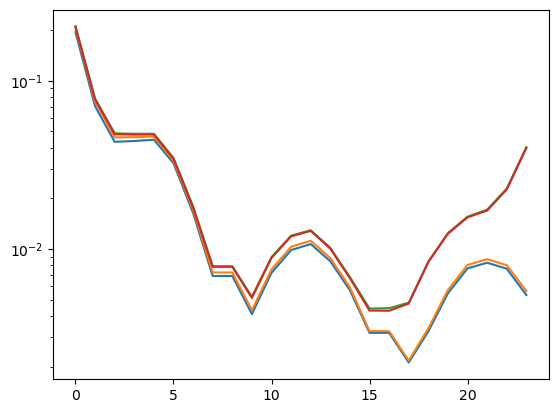

In [54]:
plt.plot(np.nanmedian(monte_carlo_results_0[15],axis=(0,1)))
plt.plot(np.nanmedian(monte_carlo_results_0[16],axis=(0,1)))

plt.plot(np.nanmedian(monte_carlo_results_0[17],axis=(0,1)))
plt.plot(np.nanmedian(monte_carlo_results_0[18],axis=(0,1)))

plt.yscale('log')

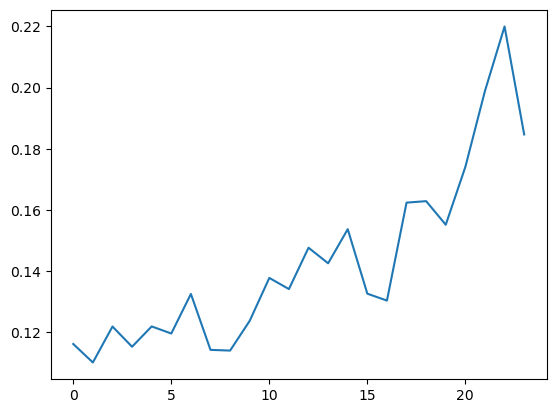

In [48]:
plt.plot((np.nanmedian(monte_carlo_results_0[13],axis=(0,1))-np.nanmedian(monte_carlo_results_0[11],axis=(0,1)))/np.flip(np.nanmedian(monte_carlo_results_0[13],axis=(0,1))))

In [93]:
(np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))[0]

array([1.03669353, 1.04006095, 1.03625509, 1.03135537, 1.02457012,
       1.01586667, 1.0099176 , 1.00706861, 1.02734933, 1.03072203,
       1.03610956, 1.03548997, 1.03249004, 1.02685157, 1.01736263,
       1.01066991, 1.0290104 , 1.02798662, 1.03136066, 1.03705963,
       1.0363387 , 1.03205531, 1.02431947, 1.01303382])

In [169]:
samples[12]

'felt side/back 4 (higher conc)'

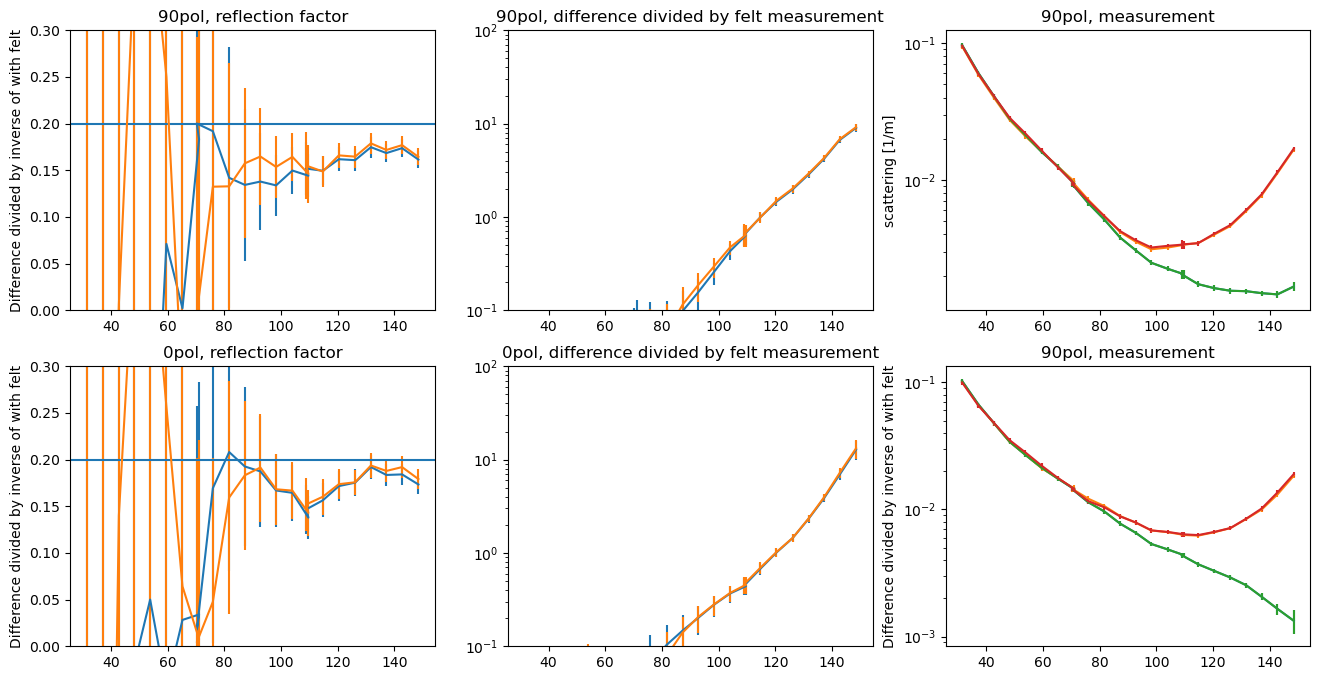

In [213]:
pol0_factors = []
pol90_factors = []

fig, ax = plt.subplots(2,3,figsize=(16,8))
# for pair in [[25,21,.6], [26,22,.6], [25,22,.6],[26,21,.6], [6,7,1], [30,32,3], [29,31,3],[9,8,1],[11,13,2.2],[15, 17,3.85],[16, 18,3.85]]:

# for pair in [[9,8,1], [10,13,2.2], [10,12,2.2], [11,12,2.2], [11,13,2.2],[15, 17,3.85],[16, 18,3.85]]: # dilution series

# for pair in [[25,21,.6], [26,22,.6], [25,22,.6],[26,21,.6]]: # 2um beads

# for pair in [[6,7,1], [6,8,1], [9,7,1], [9,8,1]]: # 700um beads

# for pair in [[30,32,3], [29,31,3], [29,32,3],[30,31,3]]: # AZ dust duplicates

for pair in [[30,32,3],[30,31,3]]: # AZ dust duplicates without low duplicate

# for pair in [[9,8,1], [10,13,2.2], [10,12,2.2], [11,12,2.2], [25,21,.6], [26,22,.6], [25,22,.6],[26,21,.6],[30,32,3], [29,31,3], [29,32,3],[30,31,3]]: # one of everything

    felt = pair[0]
    nofelt = pair[1]
    beamc = np.array(pair[2])
    
    pol0 = np.array(monte_carlo_results_90[felt])    
    med0 = np.nanmedian(pol0,axis=(0,1))
    std0 = np.nanstd(pol0,axis=(0,1))
    pol0_felt = unumpy.uarray(med0, std0)
    # plt.errorbar(angles_ssd,med0, std0,capsize=2)

    pol0 = np.array(monte_carlo_results_90[nofelt])    
    med0 = np.nanmedian(pol0,axis=(0,1))
    std0 = np.nanstd(pol0,axis=(0,1))
    pol0_nofelt = unumpy.uarray(med0, std0)
    # plt.errorbar(angles_ssd,med0, std0,capsize=2)

    est = (pol0_nofelt - pol0_felt) / ((np.flip(pol0_felt) / (np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))[0]))
    pol90_factors.append(est)
    ax[0,0].errorbar(angles_ssd,unumpy.nominal_values(est), unumpy.std_devs(est))
    
    
    est = (pol0_nofelt - pol0_felt) / pol0_felt
    ax[0,1].errorbar(angles_ssd,unumpy.nominal_values(est), unumpy.std_devs(est))

    ax[0,2].errorbar(angles_ssd,unumpy.nominal_values(pol0_felt), unumpy.std_devs(pol0_felt))
    ax[0,2].errorbar(angles_ssd,unumpy.nominal_values(pol0_nofelt), unumpy.std_devs(pol0_nofelt))

    pol0 = np.array(monte_carlo_results_0[felt])    
    med0 = np.nanmedian(pol0,axis=(0,1))
    std0 = np.nanstd(pol0,axis=(0,1))
    pol0_felt = unumpy.uarray(med0, std0)
    # plt.errorbar(angles_ssd,med0, std0,capsize=2)

    pol0 = np.array(monte_carlo_results_0[nofelt])    
    med0 = np.nanmedian(pol0,axis=(0,1))
    std0 = np.nanstd(pol0,axis=(0,1))
    pol0_nofelt = unumpy.uarray(med0, std0)
    # plt.errorbar(angles_ssd,med0, std0,capsize=2)

    est = (pol0_nofelt - pol0_felt) / ((np.flip(pol0_felt) / (np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))[0]))
    pol0_factors.append(est)
    ax[1,0].errorbar(angles_ssd,unumpy.nominal_values(est), unumpy.std_devs(est))
    
    est = (pol0_nofelt - pol0_felt) / pol0_felt
    ax[1,1].errorbar(angles_ssd,unumpy.nominal_values(est), unumpy.std_devs(est))

    ax[1,2].errorbar(angles_ssd,unumpy.nominal_values(pol0_felt), unumpy.std_devs(pol0_felt))
    ax[1,2].errorbar(angles_ssd,unumpy.nominal_values(pol0_nofelt), unumpy.std_devs(pol0_nofelt))
    
ax[0,0].axhline(.2)
ax[1,0].axhline(.2)
ax[0,0].set_ylim(0,.30)
ax[1,0].set_ylim(0,.30)
ax[0,1].set_ylim(.1,100)
ax[1,1].set_ylim(.1,100)
ax[0,2].set_yscale('log')
ax[1,2].set_yscale('log')
ax[0,1].set_yscale('log')
ax[1,1].set_yscale('log')

ax[0,0].set_title('90pol, reflection factor')
ax[0,1].set_title('90pol, difference divided by felt measurement')

ax[1,0].set_title('0pol, reflection factor')
ax[1,1].set_title('0pol, difference divided by felt measurement')

ax[0,2].set_title('90pol, measurement')
ax[1,2].set_title('90pol, measurement')


ax[0,0].set_ylabel('Difference divided by inverse of with felt')
ax[1,0].set_ylabel('Difference divided by inverse of with felt')

ax[0,2].set_ylabel('scattering [1/m]')
ax[1,2].set_ylabel('Difference divided by inverse of with felt')

plt.savefig('figs/blackfelt/analysis_azdust.png',dpi=300)
plt.show()


In [227]:
(pol90_factor_mean[-8:].mean() + pol0_factor_mean[-8:].mean())/2

0.1695653026473321+/-0.002838109956528539

NameError: name 'pol0_factor_mean' is not defined

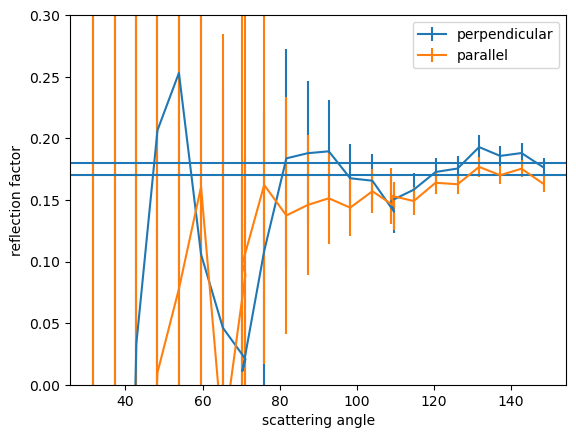

In [226]:
pol90_factor_mean = np.array(pol90_factors).mean(axis=0)
plt.errorbar(angles_ssd,unumpy.nominal_values(pol90_factor_mean), unumpy.std_devs(pol90_factor_mean), label='perpendicular')
plt.ylim(0,.3)

pol0_factor_mean = np.array(pol0_factors).mean(axis=0)
plt.errorbar(angles_ssd,unumpy.nominal_values(pol0_factor_mean), unumpy.std_devs(pol0_factor_mean), label='parallel')
plt.ylim(0,.3)

plt.axhline(.18)
plt.axhline(.17)

plt.legend()

plt.xlabel('scattering angle')
plt.ylabel('reflection factor')

plt.savefig('figs/blackfelt/aztestdust_reflection_factor.png',dpi=300)

In [ ]:
for pair in [[9,8,1], [11,13,2.2], [15, 17,3.85]]:

    felt = pair[0]
    nofelt = pair[1]
    beamc = np.array(pair[2])
    
    pol0 = np.array(monte_carlo_results_0[felt])    
    med0 = np.nanmedian(pol0,axis=(0,1))
    std0 = np.nanstd(pol0,axis=(0,1))
    pol0_felt = unumpy.uarray(med0, std0)
    # plt.errorbar(angles_ssd,med0, std0,capsize=2)

    pol0 = np.array(monte_carlo_results_0[nofelt])    
    med0 = np.nanmedian(pol0,axis=(0,1))
    std0 = np.nanstd(pol0,axis=(0,1))
    pol0_nofelt = unumpy.uarray(med0, std0)
    # plt.errorbar(angles_ssd,med0, std0,capsize=2)

    est = (pol0_nofelt - pol0_felt) / ((np.flip(pol0_felt) / (np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))[0]))

    
    plt.errorbar(angles_ssd,unumpy.nominal_values(est), unumpy.std_devs(est))
    plt.ylim(-.25,.25)
    plt.axhline(.2)
plt.show()

    # pol90 = np.array(monte_carlo_results_90[count])
    # med90 = np.nanmedian(pol90,axis=(0,1))
    # std90 = np.nanstd(pol90,axis=(0,1))
                                    
    

(-0.25, 0.25)

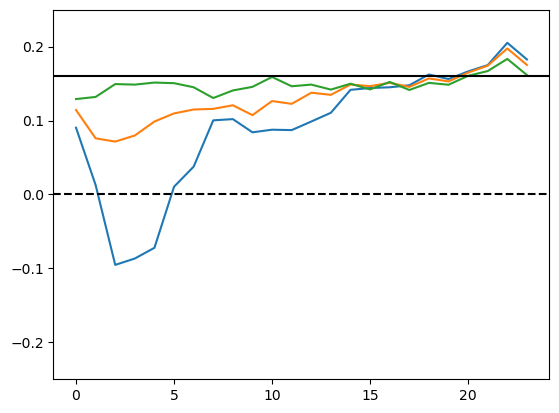

In [68]:
# 6,7 and 10,12, and 15, 17

beamc = np.array(1)
plt.plot(((np.nanmedian(monte_carlo_results_90[8],axis=(0,1)) - np.nanmedian(monte_carlo_results_90[9],axis=(0,1)))/ (np.flip(np.nanmedian(monte_carlo_results_90[8],axis=(0,1)))/(np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))))[0])
beamc = np.array(2.2)
# plt.plot((np.median(monte_carlo_results_90[7],axis=(0,1)) - np.median(monte_carlo_results_90[6],axis=(0,1)))/np.flip(np.median(monte_carlo_results_90[6],axis=(0,1))))
plt.plot(((np.nanmedian(monte_carlo_results_90[13],axis=(0,1)) - np.nanmedian(monte_carlo_results_90[11],axis=(0,1)))/ (np.flip(np.nanmedian(monte_carlo_results_90[13],axis=(0,1)))/(np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))))[0])
beamc = np.array(3.85)
# plt.plot((np.median(monte_carlo_results_90[32],axis=(0,1)) - np.median(monte_carlo_results_90[30],axis=(0,1)))/np.flip(np.median(monte_carlo_results_90[32],axis=(0,1))))
plt.plot(((np.nanmedian(monte_carlo_results_90[17],axis=(0,1)) - np.nanmedian(monte_carlo_results_90[16],axis=(0,1)))/ (np.flip(np.nanmedian(monte_carlo_results_90[17],axis=(0,1)))/(np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))))[0])

plt.axhline(0.16,c='k')

plt.axhline(0,c='k',ls='--')

plt.ylim(-.25,.25)

(-0.25, 0.25)

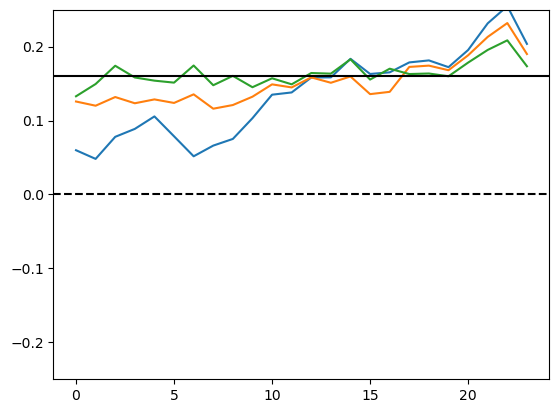

In [89]:
# 6,7 and 10,12, and 15, 17

beamc = np.array(1)
plt.plot(((np.nanmedian(monte_carlo_results_0[8],axis=(0,1)) - np.nanmedian(monte_carlo_results_0[9],axis=(0,1)))/ (np.flip(np.nanmedian(monte_carlo_results_0[8],axis=(0,1)))/(np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))))[0])
beamc = np.array(2.2)
# plt.plot((np.median(monte_carlo_results_90[7],axis=(0,1)) - np.median(monte_carlo_results_90[6],axis=(0,1)))/np.flip(np.median(monte_carlo_results_90[6],axis=(0,1))))
plt.plot(((np.nanmedian(monte_carlo_results_0[13],axis=(0,1)) - np.nanmedian(monte_carlo_results_0[11],axis=(0,1)))/ (np.flip(np.nanmedian(monte_carlo_results_0[13],axis=(0,1)))/(np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))))[0])
beamc = np.array(3.85)
# plt.plot((np.median(monte_carlo_results_90[32],axis=(0,1)) - np.median(monte_carlo_results_90[30],axis=(0,1)))/np.flip(np.median(monte_carlo_results_90[32],axis=(0,1))))
plt.plot(((np.nanmedian(monte_carlo_results_0[17],axis=(0,1)) - np.nanmedian(monte_carlo_results_0[16],axis=(0,1)))/ (np.flip(np.nanmedian(monte_carlo_results_0[17],axis=(0,1)))/(np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor))))[0])

plt.axhline(0.16,c='k')

plt.axhline(0,c='k',ls='--')

plt.ylim(-.25,.25)

In [ ]:
cscatSsdUncal-np.flip(cscatSsdUncal) *(mirror) /np.exp(mirror_attenuation_pathlengths*beamc.reshape(-1,1)/atten_factor)

In [ ]:
(full - blackfelt) / np.flip(full)

MIE DATA

In [10]:
bead_samples = [.2,.2,.2,.2,.2,
               .2,.2,.2,.2,
               2,2,2,2,
               .06,.06,.06,.06,
               .7,.7,.7,.7,]

In [11]:
bead_samples[10],bead_samples[20]

(2, 0.7)

In [12]:
fn = 'full_mie_meas_oo25.mat'
mat = scipy.io.loadmat(fn)
full_mie_meas = mat['full_mie_meas']

fn = 'full_angles_mie.mat'
mat = scipy.io.loadmat(fn)
full_angles_mie = mat['full_angles_mie']

# this is directly from matlab
mie_beamc = [1.0172e-05,	0.004765,	0.8422,	6.550]

full_mie_meas[:,0] = full_mie_meas[:,0]/mie_beamc[0]
full_mie_meas[:,1] = full_mie_meas[:,1]/mie_beamc[1]
full_mie_meas[:,2] = full_mie_meas[:,2]/mie_beamc[2]
full_mie_meas[:,3] = full_mie_meas[:,3]/mie_beamc[3]

In [13]:
full_mie_meas.shape

(2, 4, 2001)

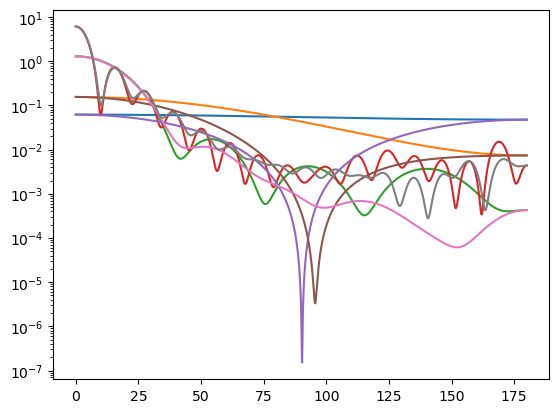

In [14]:
plt.plot(full_angles_mie,full_mie_meas[0,:,:].T)
plt.plot(full_angles_mie,full_mie_meas[1,:,:].T)
plt.yscale('log')

In [15]:
# mie beads = [0.060, 0.202, 0.700, 2.020]

bead_samples = [.2,.2,.2,.2,.2,
               .2,.2,.2,.2,
               2,2,2,2,
               .06,.06,.06,.06,
               .7,.7,.7,.7,]

mie_all_runs = [full_mie_meas[:,1],full_mie_meas[:,1],full_mie_meas[:,1],full_mie_meas[:,1],full_mie_meas[:,1],
               full_mie_meas[:,1],full_mie_meas[:,1],full_mie_meas[:,1],full_mie_meas[:,1],
               full_mie_meas[:,3],full_mie_meas[:,3],full_mie_meas[:,3],full_mie_meas[:,3],
               full_mie_meas[:,0],full_mie_meas[:,0],full_mie_meas[:,0],full_mie_meas[:,0],
               full_mie_meas[:,2],full_mie_meas[:,2],full_mie_meas[:,2],full_mie_meas[:,2],]

mie_all_runs = np.array(mie_all_runs)

In [16]:
mie_all_runs.shape

(21, 2, 2001)

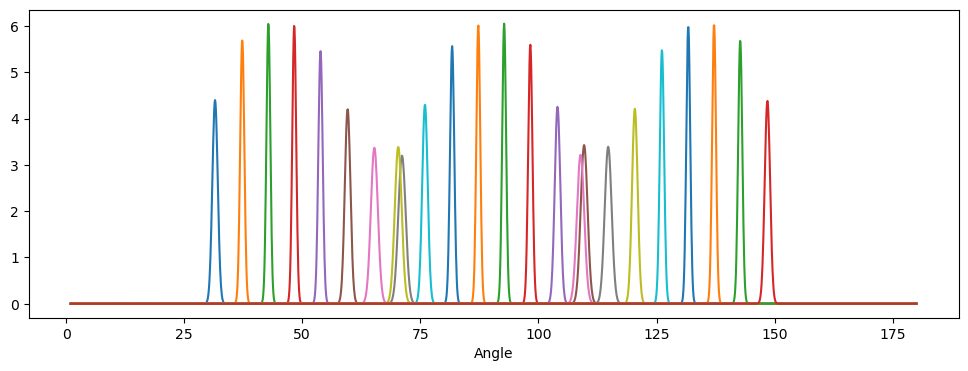

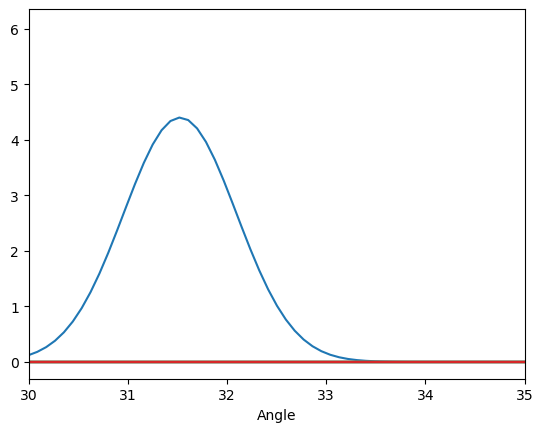

In [17]:
theta = np.linspace(1,180,2001)
# theta = np.repeat(np.reshape(theta,[-1,1]),24,axis=1)

fig, ax = plt.subplots(figsize=(12,4))

# expected response function of each detector
alpha=1
sigma = widths_ssd*.2

W_thetas = []
for i in range(24):
    W_theta = alpha*(1/sigma[i]*np.sqrt(2*np.pi))*np.e**(-0.5*((theta-angles_ssd[i])/sigma[i])**2)
    W_thetas.append(W_theta)
    plt.plot(theta,W_theta)

plt.xlabel('Angle')
plt.show()

for i in range(24):
    W_theta = alpha*(1/sigma[i]*np.sqrt(2*np.pi))*np.e**(-0.5*((theta-angles_ssd[i])/sigma[i])**2)
    plt.plot(theta,W_theta)

plt.xlim(30,35)
plt.xlabel('Angle')
plt.show()

In [18]:
mie_convolved0 = []
mie_convolved1 = []
for idx in range(len(mie_all_runs)):
    mie_convolved0.append((mie_all_runs[idx,0]* np.array(W_thetas)).sum(axis=1)/70.2)
    mie_convolved1.append((mie_all_runs[idx,1]* np.array(W_thetas)).sum(axis=1)/70.2)

mie_convolved0 = np.array(mie_convolved0)
mie_convolved1 = np.array(mie_convolved1)

mie_perp_raw = mie_all_runs[:,0]
mie_para_raw = mie_all_runs[:,1]

In [19]:
mie_perp_modeled = mie_convolved0+mie_convolved1*0.03
mie_para_modeled = mie_convolved1+mie_convolved0*0.03